![alt text](images/uspas.png)
# Fundamentals of Accelerator Physics and Technology
### (with Simulations and Measurements Lab)
# Computer Lab: Dispersion and Chromaticity in Simulated Beam Transport
##### Authors: K. Ruisard, N. Evans, N. Neveu and L. Dovlatyan

## We will be simulating beam transport in simple beamlines. To do this, we will be running the Elegant code in the [Sirepo](https://beta.sirepo.com) environment. Questions to be turned in for credit are in **bold** and numbered.
### Python Notes:
- You wont need much python specific code for this lab, but here are some tips:
- Press shift+enter to execute a cell, or use the play button at the top of the window
- Make sure you execute cells in order, or re-execute cells if you change something at the top of the notebook.
- You can also execute the whole notebook by using 'Run all cells' under the 'Run' tab.

</br>
Also helpful: Shift+right click brings up OS/browser right-click menu, can copy image or save.

----------

## 1. Dispersion and Chromaticity

### A) Dispersion in FODO lattice

In other labs, we simulate beamlines without dipoles. Dipoles create dispersion ($\eta$ or D, depending who you talk to), which describes the evolution of transverse size for particles/beams that are off-momentum. Off-momentum particles experience a different force in the dipole than the design orbit, as they have different magnetic rigidity $B\rho=\frac{p}{q}$. Dispersion is a function of s and can have a periodic (matched) solution, similar to the $\beta$ and $\alpha$ functions.

The initial conditions for this simulation:

| Species  | Election  |   
|---|---|
| Energy  | 1 GeV  |   
|  X emittance | $\epsilon_x = 6$ mm-mrad  |  
|  Y emittance |  $\epsilon_y = 6$ mm-mrad |  
|  Quadrupole geometric strength | $K = 0.6$ m$^{-2}$|
|  FODO cell length | $L = 5$ m|

Open simulation “FODObeamline-with-dipole”
> https://www.sirepo.com/elegant#/source/SMHkFUFD

Initially, this simulation lattice is a FODO cell that is identical to the cell used in the FODO-transport lab.

- Go to Visualization tab at top of the page.
- Run simulation to run over 1 cell (make sure beamline "FODOcell" is selected).
- verify that calculated solution is matched. If not, under Tab: Control -> twiss_output, Change Matched to Yes and re-run simulation.
- Note down matched beam size (Sx and Sy in the run_setup.sigma plot) at the location of the quads QF and QD for future reference.


Next, add a dipole element to your FODO cell:
- Go to the 'Lattice Tab' at the top of the screen
- Under 'Beamlines', hover over FODOcell, and click 'Edit'
- Delete the 0.5 meter drift "D3" and, in its place, add the RBEN element "DIPO"
- "DIPO" is a 20-degree dipole with rectangular geometry (as opposed to sector geometry, which is also an option).
- Run simulation over modified FODO cell


#### A comment on dipole edge focusing
First, scroll to the sigma_output plot to observe the effect of the dipole on the beam moments.

Note that the sigma_output plot is generated by tracking a particle distribution through the cell. This distribution does not include a momentum spread, so dispersion should not affect the results of this plot.

However, you will observe that Sx looks slightly different from the case without a dipole. There is a small de-focusing kick at the entrance of the dipole, and a small focusing kick at the exit of the dipole. These two kicks cancel, and the periodic solution in the horizontal plane is almost identical to the FODO cell without a dipole.

In contrast, the average value of Sy has decreased significantly, and there is a focusing kick at the entrance and exit. The dipole has a net focusing effect in the vertical plane.

The reason for these differences is an effect called *edge focusing*, which is caused by fringe fields that extend past the edge of the dipole. An exploration of edge focusing is beyond the scope of this lab, but it is good to be aware that this is another way in which dipoles affect the lattice and beam parameters. Edge focusing is an effect which does not depend on beam energy spread. In contrast, the strength of the effects caused by dispersion and chromaticity do depend on energy spread in the particle distribution - which is mainly determined by the RF system used for acceleration.

#### Effect of dispersion on beam size

Scroll down and to the twiss_output plot.
Observe dispersion $\eta_x$ (etax).

hint: to see dispersion function at an appropriate scale, turn off $\beta_x$ and $\beta_y$ curves by un-checking the boxes.



**Q1) What is minimum dispersion in this lattice? At what location does this occur (focusing quad, defocusing quad or drift)?\
If we compare this lattice to an identical FODO cell without the dipole, would the horizontal beam size at this location be larger or smaller?  
What about the vertical beam size?**


**Q2) Assuming a 0.1% momentum spread ($\frac{\delta p}{p}=0.001$) in the beam, what is the horizontal beam size we expect in the focusing quadrupole QF? How does this compare to our beam size without energy spread? \
What is the vertical beam size in QF with and without energy spread?**

Use max eta and the $\epsilon_x$ from above.

you may find this formula helpful: $\sigma_x^2 = \epsilon_x \beta_x+ \eta_{max}^2 \left( \frac{\Delta p}{p_0} \right)^2$, where $\Delta p/p $ is the fractional momentum spread.

You can check your calculation against simulation by introducing a momentum spread. Under the "Control" tab, edit "bunched_beam", Page 3, "Sigma DP," where Sigma DP $ = \Delta p / p_0$. The result will not be identical but should be within ~0.2 mm.


|           | $\delta = 0$ | $\delta = 0.001$ |  
|---        |---           |---               |
|$\sigma_x$ |              |                  |
|$\sigma_y$ |              |                  |

### B) Designing a zero-dispersion insert

Open simulation DispersionFree:
> https://www.sirepo.com/elegant#/source/dW4biLsM

The lattice cell in this simulation has two 18-degree bends and five quadrupoles.  
The quadrupole fields are initially set to zero and matching is disabled.  
- Run the simulation and observe the evolution of the dispersion $\eta_x$ through the double bend.


**Q3) What is $\eta_x$ and $\eta_x'$ at the end of the cell?**

- Go to 'Lattice' at the top of the page.
- “Turn on” the middle quadrupole (Q1) at $k_1=1\ m^{-2}$. Note the effect this has on the dispersion function.
- Adjust the strength of Q1 to find the solution for which dispersion is zero after the two bends.
- Hint: you will need to restart the simulation after you change K.

**Q4) What is the strength you found?** Give your answer with at least two decimal places.


$k_1$ =

Enable matching (Under the Control tab -> twiss_output command -> set “Matched” to “yes”).  
- Run simulation; you should see that beamline is unstable, i.e. there are no periodic solutions.
Let’s add some additional focusing to correct that.
- “Turn on” the flanking quadrupoles by setting Q2: $k_1=1.33\ m^{-2}$ and Q3: $k_1=-1.59\ m^{-2}$.
- Re-run to find matched solution.

Congrats! You’ve made a double-bend achromat. This is useful for light sources, where sections with zero dispersion are used for placing radiation-generating inserts like undulators and wigglers. Note that dispersion is cancelled for only part of the cell - it is not zero everywhere.

**Q5) What is the maximum dispersion in this cell?**

$\eta_x = $

#### Momentum acceptance limited by dispersion

Because the effect of dispersion depends on the beam momentum spread, it presents a limit to the amount of spread that can be transported without losing particles.

**Q6) Assuming the vacuum chamber is a pipe with 2.5 cm radius, what is the largest momentum spread that can be tolerated before particles start to hit the chamber wall ?**

You will need to use this equation again: $\sigma_x^2 = \epsilon_x \beta_x+ \eta^2 \left( \frac{\Delta p}{p_0} \right)^2$

**Q7) If momentum spread exceeds this limit, where in the cell will beam loss occur?**

You can check your answers to Q6) and Q7) against simulation by introducing a momentum spread into the beam. To do this, follow the same instructions as under Q2).

### C) Chromaticity in a ring

Repeat your cell 10 times to create a ring.
- Under the Lattice tab, make a new beamline.
- Fill it with DBA elements.
- Rerun the simulation under the Visualization tab.
- Make sure you select your new beamline from the drop down menu.


Although sections of this lattice are dispersion-free, this ring still has chromaticity. In other words, although off-momentum particles do not increase the beam size in the dispersion-free sections, they still feel a different focusing strength than the *synchronous* or on-energy particle and, as a results, have a slightly different *tune*. Recall that tune is the frequency of particle oscillation around the design particle.  

First we will calculate the tune of the on-energy particles, then calculate the spread of tune that results from momentum spread.



**Q8) Record x and y tunes (to 3 significant figures):**

The tunes are "nux" and "nuy" in the "Output Parameters" list

$\nu_x = $   
$\nu_y = $

**Q9) In our FODO cell, we apply equal focusing strengths in both planes and as a result, $\nu_x=\nu_y$. Looking at the beta functions for one DBA cell, explain why you would not necessarily expect the tunes to be equal.**


**Q10) For a 0.1% momentum spread in the beam, what is the spread of tunes due to chromaticity?**


In the Output Parameters list, look for dnux/dp and dnuy/dp which are the chromaticity values:

$C_x = $

$C_y = $

Use $\Delta \nu = C \frac{\Delta p}{p_0}$  to calculate tune spread:

$\Delta \nu_x = $

$\Delta \nu_y = $

#### Momentum acceptance limit due to chromaticity

When operating a ring, we have to carefully choose the tune to avoid resonant conditions, which may cause instability in the particle trajectories. Small errors in our lattice can resonate with the beam motion when there is a rational relationship between the tunes.

A rational relationship is one that satisfies $m \nu_x + n \nu_y = p$ for any integers $m$,$n$,$p$. The order of the resonance is $|m|+|n|$. Generally speaking, driving terms for higher-order resonances are weaker.

Which resonance lines and orders of resonance need to be avoided are unique to each accelerator facility. Here we will assume that the ring we just designed needs to be operated away from all resonances at 3rd order and below. We will use the plot below to visualize how the chromatic tune spread might affect our operation.

In [1]:
## This cell includes the function that makes the plot below. You don't need to look at it, just execute it once.

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

def tunediagram(order=range(1,4),integer=[0,0],lines=[1,1,1,1],colors='ordered',linestyle='-',fig=plt.gcf(),legend=True):
    '''
    plot resonance diagram up to specified order
    mx + ny = p
    x = (p-ny)/m
    x = 1 where y = (p-m)/n
    EXAMPLE:
       tunediagram(order=[1,2,3])
       tunediagram([1,2,3],integer=[6,8],lines=[0,0,1,1])
       tunediagram([1,2,3],integer=[6,8],lines=[0,0,1,1], colors='black3', linestyle='--')
    INPUT:
      1. order - array of tune orders to plot. e.g. up to 3rd order, [1,2,3]
      2. integers - integer part of the tune to plot in x,y, default is [0,0]. e.g. plot from 6-7 and 9-10, integer=[6,9]
      2. lines - a boolean of which resonance lines to plot. e.g. [vertical,horizontal,sum,diff]. e.g. plot only vert/horz lines, lines = [1,1,0,0]
      4. colors - option to plot lines in different colors. default is ordered. color options only go up to 10th order
        ordered - each order resonance is a different color
        black - all lines are black
        blackX - X here is a number. all resonances X+ will be in black. e.g. black3 means plot resonances 1-2 in color and 3,4,5,... in black
      6. linestyle - linestyle option from matplotlib
      7. fig - pass in a handle to a figure, otherwise things will be plotted in the current figure.
    Written by Levon Dovlatyan
    University of Maryland, Department of Physics
    Oct 2018
    '''
    # define some variables
    pval = 40 # increase for more/higher order lines
    p = np.linspace(0,pval,pval+1)

    qxmin,qymin = integer[0],integer[1]
    qxmax,qymax = qxmin+1,qymin+1

    # define different colors, up to 10th order
    color = ['C0','C1','C2','C3','C4','C5','C6','C7','C8','C9']
    if colors == 'black':
        color = ['k']*10
    elif colors[0:-1] == 'black':
        idx = int(colors[-1])
        color = color[0:idx-1] + (['k']*10)[idx-1:]

    # adjust plot limits
    plt.xlim((qxmin-0.01, qxmax+0.01))
    plt.ylim((qymin-0.01, qymax+0.01))

    # hold legend objects
    legend_elements = []

    # Plotting formula
    # we plot resonances in reverse order
    for i in order[::-1]:
        # -- legend
        legend_elements.append(Line2D([0], [0], color=color[i-1], linestyle=linestyle, label='order %i'%i))

        # -- resonance line
        m = np.linspace(-i,i,2*i+1)
        n1 = (i-np.abs(m))
        n2 = -1*n1
        for j in range(0,m.size,1):
            # check to see equation is divided by 0 or not
            # ver & hor res lines
            if ((n1[j] == 0 and lines[1]) or (m[j] == 0 and lines[0])):
                # vertical lines
                if n1[j] == 0 and lines[1]:
                    plt.vlines(p/m[j],qymin,qymax,color=color[i-1],linestyle=linestyle);
                # horizontal lines
                if m[j] == 0 and lines[0]:
                    plt.hlines(p/n1[j],qxmin,qxmax,color=color[i-1],linestyle=linestyle);
                    plt.hlines(p/n2[j],qxmin,qxmax,color=color[i-1],linestyle=linestyle);
            # sum and dif res lines
            elif not(n1[j] == 0) and not(m[j] == 0):
                # resonance sum lines
                if lines[2]:
                    if np.sign(m[j]) > 0:
                        plt.plot([[qxmin]*p.size,[qxmax]*p.size],[p/n2[j] - np.array(m[j]*qxmin/n2[j]), p/n2[j] - np.array(m[j]*qxmax/n2[j])],color=color[i-1],linestyle=linestyle);
                    else:
                        plt.plot([[qxmin]*p.size,[qxmax]*p.size],[p/n1[j] - np.array(m[j]*qxmin/n1[j]), p/n1[j] - np.array(m[j]*qxmax/n1[j])],color=color[i-1],linestyle=linestyle);
                # resonance dif lines
                if lines[3]:
                    if np.sign(m[j]) > 0:
                        plt.plot([[qxmin]*p.size,[qxmax]*p.size],[p/n1[j] - np.array(m[j]*qxmin/n1[j]), p/n1[j] - np.array(m[j]*qxmax/n1[j])],color=color[i-1],linestyle=linestyle);
                    else:
                        plt.plot([[qxmin]*p.size,[qxmax]*p.size],[p/n2[j] - np.array(m[j]*qxmin/n2[j]), p/n2[j] - np.array(m[j]*qxmax/n2[j])],color=color[i-1],linestyle=linestyle);

    if legend:
        legend_elements.reverse()
        plt.legend(handles=legend_elements, loc='upper left',bbox_to_anchor=(1,1))

<Figure size 640x480 with 0 Axes>

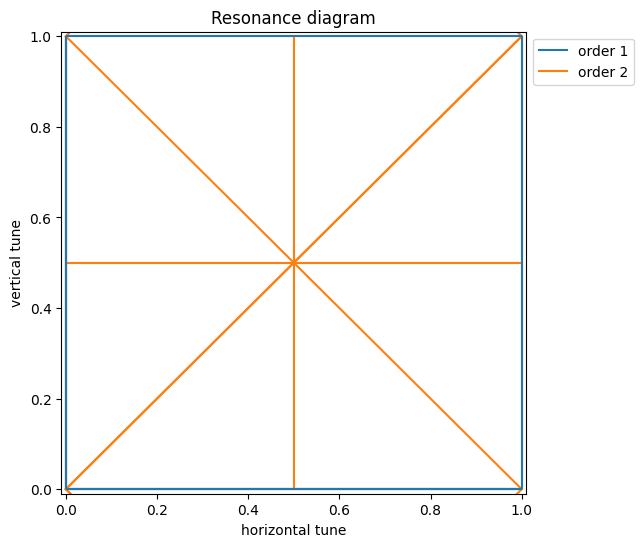

In [2]:
# This cell creates a resonance diagram with the tune footprint for our ring indicated.
# for this cell to work, make sure you execute the previous cell.

##########################
## Change these parameters
##########################
nux = 0
nuy = 0
sigma_dp = 0
Cx = 0
Cy = 0
resonance_order = 2

##########################
## don't change below
##########################
delta_nux = Cx*sigma_dp
delta_nuy = Cy*sigma_dp


#from tunediagram import tunediagram
import matplotlib.pyplot as plt
plt.figure(figsize=[6,6])

# -- plot resonance lines
tunediagram(order=range(1,resonance_order+1),integer=[int(nux),int(nuy)])
plt.title('Resonance diagram')
plt.ylabel('vertical tune'); plt.xlabel('horizontal tune');

# -- plot tune footprint over resonance lines
if (nux!=0) & (nuy!=0):
    plt.plot([nux],[nuy],'ko',label='ring tune')
    plt.plot([nux+delta_nux,nux-delta_nux],[nuy+delta_nuy,nuy-delta_nuy],'k.')
    plt.plot([nux-delta_nux,nux+delta_nux],[nuy-delta_nuy,nuy+delta_nuy],'k-');


**Q11) Assuming we can tolerate resonances of order 4 and above, but cannot operate on resonances of order 3 and below, how big of a momentum spread can we tolerate in this ring?** Using the plot above, set `resonance_order=3` and plug in the values for tunes and chromaticity that you recorded above. Adjust the momentum spread `sigma_dp` until your tune spread (the black line) crosses a resonance line. Give your answer to the nearest 0.1%



**Q12) Comparing your answers to Q6 and Q11, is the momentum acceptance of this ring limited by chromaticity or by dispersion?**